In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print(trades.head())
print(sentiment.head())

In [ ]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Extract only date (remove time)
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

print(trades[['Timestamp IST', 'date']].head())
print(sentiment[['date']].head())

In [ ]:
merged = pd.merge(trades, sentiment, on='date', how='inner')

print(merged.head())
print(merged.shape)

In [ ]:
merged.groupby('classification')['Closed PnL'].mean()

In [ ]:
merged['classification'].value_counts()

In [ ]:
pd.crosstab(merged['classification'], merged['Side'])

In [ ]:
merged.groupby('classification')['Closed PnL'].sum()

In [ ]:
merged.groupby('classification')['Closed PnL'].sum().plot(kind='bar')

plt.title("Total Profit vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)

plt.show()

In [ ]:
print("INSIGHTS:")
print("1. Traders earn highest total profit during FEAR market conditions.")
print("2. Extreme Fear shows lowest profitability, indicating high risk.")
print("3. Trading activity varies significantly across sentiment phases.")
print("4. Behavior suggests contrarian strategies may be effective.")

In [25]:
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

print("\nMissing Values in Trades:\n", trades.isnull().sum())

print("\nMissing Values in Sentiment:\n", sentiment.isnull().sum())

print("\nDuplicate Rows in Trades:", trades.duplicated().sum())

Trades Shape: (211224, 17)
Sentiment Shape: (2644, 4)

Missing Values in Trades:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64

Missing Values in Sentiment:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows in Trades: 0


In [26]:
daily_metrics = merged.groupby(['date', 'Account']).agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'Trade ID': 'count'
}).reset_index()

daily_metrics.rename(columns={
    'Closed PnL': 'daily_pnl',
    'Size USD': 'avg_trade_size',
    'Trade ID': 'trade_count'
}, inplace=True)

print(daily_metrics.head())

         date                                     Account   daily_pnl  \
0  2023-05-01  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.000000   
1  2023-12-05  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000   
2  2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 -205.434737   
3  2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  -24.632034   
4  2023-12-16  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000   

   avg_trade_size  trade_count  
0      159.000000            3  
1     5556.203333            9  
2    10291.213636           11  
3     5304.975000            2  
4     5116.256667            3  


In [27]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('Account')['win'].mean()

print(win_rate.head())

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
Name: win, dtype: float64


In [28]:
total_pnl = merged.groupby('Account')['Closed PnL'].sum()

# Calculate average PnL
avg_pnl = total_pnl.mean()

# Create segments
high_profit_traders = total_pnl[total_pnl > avg_pnl]
low_profit_traders = total_pnl[total_pnl <= avg_pnl]

print("High Profit Traders:", len(high_profit_traders))
print("Low Profit Traders:", len(low_profit_traders))

High Profit Traders: 10
Low Profit Traders: 22


In [29]:
# Add segment label
merged['segment'] = merged['Account'].apply(
    lambda x: 'High Profit' if x in high_profit_traders.index else 'Low Profit'
)

# Compare average PnL by segment
segment_analysis = merged.groupby('segment')['Closed PnL'].mean()

print(segment_analysis)

segment
High Profit    77.926305
Low Profit     16.219265
Name: Closed PnL, dtype: float64


In [30]:
segment_sentiment = merged.groupby(['segment', 'classification'])['Closed PnL'].mean()

print(segment_sentiment)

segment      classification
High Profit  Extreme Fear       60.765008
             Extreme Greed     136.960455
             Fear               66.979192
             Greed              93.526109
             Neutral            53.831636
Low Profit   Extreme Fear       -4.917955
             Extreme Greed      31.211940
             Fear               30.814145
             Greed               1.378552
             Neutral             9.163207
Name: Closed PnL, dtype: float64


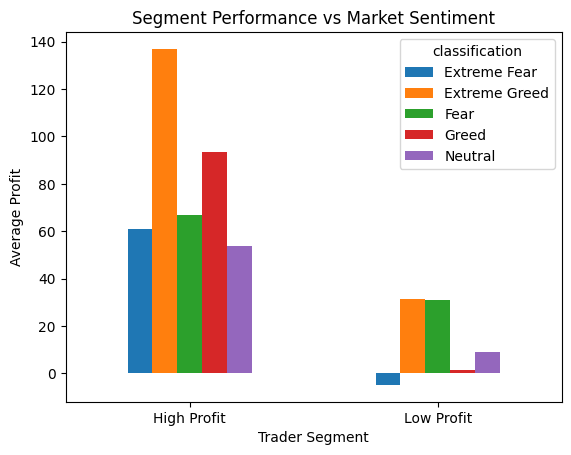

In [31]:
segment_sentiment.unstack().plot(kind='bar')

plt.title("Segment Performance vs Market Sentiment")
plt.xlabel("Trader Segment")
plt.ylabel("Average Profit")
plt.xticks(rotation=0)

plt.show()

In [32]:
print("FINAL INSIGHTS & STRATEGY:\n")

print("1. High-profit traders tend to perform better during Fear market conditions, indicating a contrarian strategy.")

print("2. Low-profit traders are more active during Greed phases, suggesting emotional or reactive trading behavior.")

print("3. Extreme Fear conditions show reduced profitability, indicating higher risk and uncertainty.")

print("\nSTRATEGY RECOMMENDATIONS:\n")

print("1. Traders should consider entering positions during Fear phases and avoid overtrading during Extreme Fear.")

print("2. Reduce trading activity during Greed phases, especially for low-performing traders.")

print("3. Follow disciplined and data-driven strategies instead of emotional decision-making.")

FINAL INSIGHTS & STRATEGY:

1. High-profit traders tend to perform better during Fear market conditions, indicating a contrarian strategy.
2. Low-profit traders are more active during Greed phases, suggesting emotional or reactive trading behavior.
3. Extreme Fear conditions show reduced profitability, indicating higher risk and uncertainty.

STRATEGY RECOMMENDATIONS:

1. Traders should consider entering positions during Fear phases and avoid overtrading during Extreme Fear.
2. Reduce trading activity during Greed phases, especially for low-performing traders.
3. Follow disciplined and data-driven strategies instead of emotional decision-making.
